# Nepal Script Text Recognition From Ancient Artifacts: Challenges and Opportunities
### Authors:
#### Swornim Nakarmi, Sarin Sthapit, Sahil Ratna Tuladhar, Arya Shakya, Bal Krishna Bal, Rajani Chulyadyo

---

This notebook demonstrates the end-to-end OCR inference pipeline for recognizing Nepal Script text from stone inscription images.

The pipeline consists of three main stages:
1. **Image Loading**: load and resize the input image
2. **Line Segmentation**: detect and crop individual text lines using a YOLO-based model
3. **Text Recognition**: transcribe each line using a CRNN model with CTC decoding

![Overall OCR Pipeline](images/ocr_pipeline.jpg)

The diagram above illustrates the full pipeline from inscription photo to recognized text:

- **Input Image**: a photograph of a cleaned Nepal Script stone inscription
- **Text Line Detection with YOLO**: a YOLO object detection model localizes each line of text
- **Segmented Text Line Images**: each detected bounding box is cropped from the original image and letterboxed to a fixed resolution of 508×64 pixels
- **Segmented Text Line Images in Grayscale**: the cropped line segments are converted to single-channel grayscale to match the input format expected by the recognition model
- **Recognized Text**: the CRNN model processes each grayscale segment and outputs a decoded Unicode string

### Import Libraries

In [1]:
import cv2
import onnxruntime
import numpy as np
import pandas as pd
import supervision as sv
from utils.image_loader import ImageLoader, LineSegmenter
from utils.ocr_pipeline import OCRPipeline

### Load and Display Image

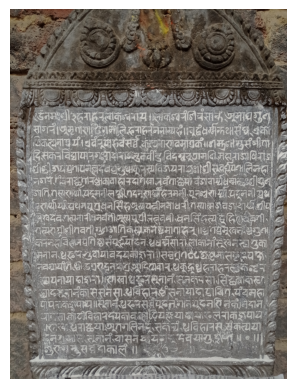

In [2]:
image = ImageLoader(image_path='images/chhusya_bahal.jpg')
image.show()

### Resize to 1024x1024 using letterboxing to preserve aspect ratio

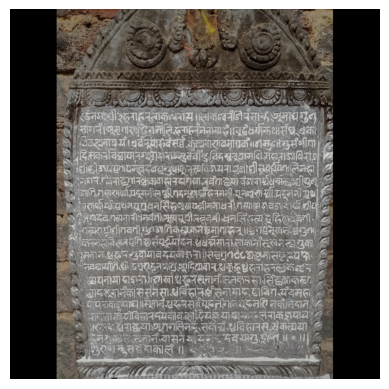

In [3]:
image.resize()
image.show_resized()

### Detect and Segment Text Lines

In [4]:
line_segmenter = LineSegmenter(image=image.resized_image, model_path='models/line_detection_model.onnx')

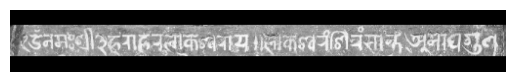

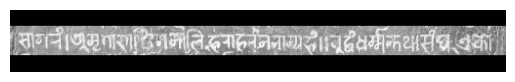

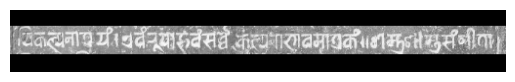

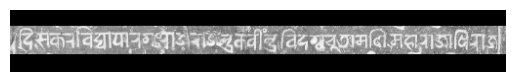

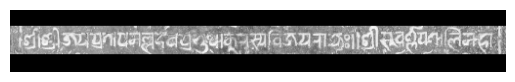

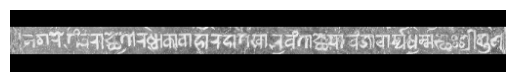

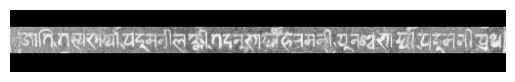

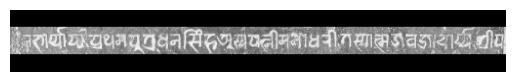

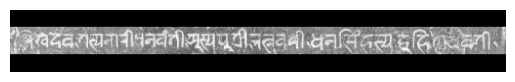

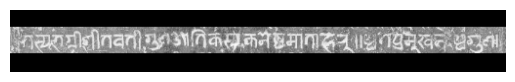

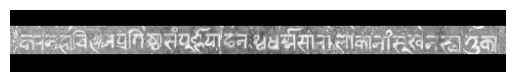

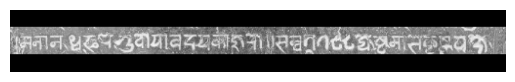

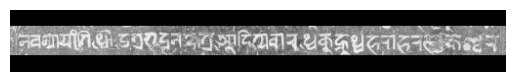

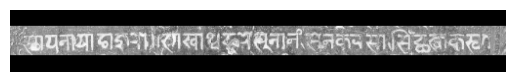

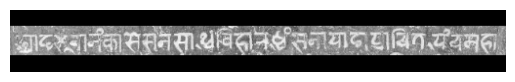

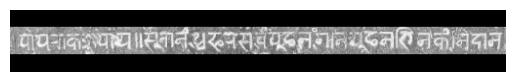

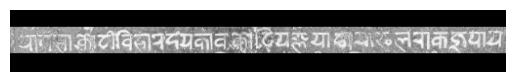

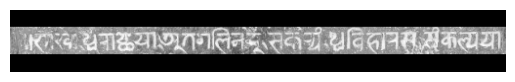

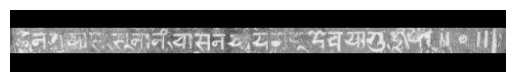

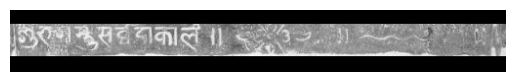

In [5]:
# Run line detection model and crop each detected line
line_segmenter.segment_lines()
line_segmenter.show_segments()

In [6]:
# Retrieve cropped grayscale line segments for OCR input
line_segments = line_segmenter.get_segments()

### Run OCR and Recognize Text

In [7]:
ocr_pipeline = OCRPipeline(
    line_segments=line_segments,
    model_path='models/ocr_model.onnx',
    charset_path='assets/charset.csv'
)

In [8]:
text = ocr_pipeline.recognize_text()
text = '\n'.join(text)
print(text)

𑑊𑑉𑐣𑐩𑑅𑐱𑑂𑐬𑐷𑑓𑐴𑐬𑐵𑐴𑐬𑐮𑑀𑐎𑐱𑑂𑐰𑐬𑐵𑐫𑑌𑐮𑑀𑐎𑐱𑑂𑐰𑐬𑑄𑐱𑐶𑐬𑑄𑐳𑐵𑐣𑑂𑐟𑑍𑐀𑐣𑐵𑐢𑐐𑐸𑐞
𑐳𑐵𑐐𑐬𑑄𑑌𑐀𑐩𑐺𑐟𑐵𑐨𑐵𑐢𑐶𑐣𑐣𑐵𑐮𑐶𑐴𑐬𑐵𑐴𑐬𑐣𑐬𑐵𑐐𑑂𑐫𑐴𑑄𑑌𑐧𑐸𑐡𑑂𑐢𑐬𑑂𑐩𑑂𑐩𑐣𑑂𑐟𑐠𑐵𑐳𑑄𑐑𑐊𑐎𑑀
𑐫𑐶𑐎𑐮𑑂𑐫𑐣𑐵𑐟𑑂𑐬𑐫𑑄𑑋𑐊𑐰𑑄𑐬𑐸𑐥𑐵𑐴𑐰𑑄𑐳𑐬𑑂𑐰𑑂𑐰𑑍𑐎𑐮𑐟𑑂𑐥𑐬𑐵𑐨𑐵𑐰𑐩𑐵𑐟𑑂𑐬𑐎𑑄𑑌𑐱𑐬𑐩𑑂𑐡𑑂𑐬𑐱𑐵𑐳𑑂𑐟𑐸𑐳𑑄𑐱𑐷𑐟𑐵
𑐡𑐶𑐳𑐎𑐬𑐰𑐶𑐡𑑂𑐫𑐵𑐥𑐵𑐬𑐐𑐬𑐵𑐌𑐬𑑀𑐄𑐣𑑂𑐡𑑂𑐬𑐎𑐰𑐷𑐣𑑂𑐡𑑂𑐬𑐰𑐶𑐡𑐐𑑂𑐔𑐸𑐜𑐵𑐩𑐞𑐶𑐩𑐴𑐵𑐬𑐵𑐖𑐵𑐢𑐶𑐬𑐵𑐖
𑐱𑑂𑐬𑐷𑐱𑑂𑐬𑐷𑐖𑐫𑐥𑑂𑐬𑐞𑐵𑐥𑐩𑐮𑑂𑐮𑐡𑐾𑐰𑐥𑑂𑐬𑐱𑐸𑐠𑐵𑐎𑐸𑐬𑐳𑑂𑐫𑐰𑐶𑐖𑐫𑐬𑐵𑐖𑑂𑐬𑑅𑑌𑐱𑑂𑐬𑐷𑐳𑐸𑐬𑑂𑐰𑐬𑑂𑐞𑑂𑐞𑐥𑐱𑐵𑐮𑐶𑐣𑐴𑐵
𑐣𑐐𑐬𑐾𑐟𑑄𑐔𑐬𑐵𑐕𑐾𑐱𑑂𑐷𑐬𑐢𑑂𑐵𑐎𑐵𑐧𑐵𑐴𑐵𑐬𑐡𑐵𑐟𑐏𑐵𑐬𑐰𑑄𑐟𑐵𑐕𑐫𑐵𑐧𑐖𑐵𑐔𑐵𑐬𑑂𑐫𑑂𑐫𑐢𑐬𑑂𑐩𑑂𑐩𑐟𑑂𑐫𑑅𑐱𑑂𑐬𑐷𑐐𑐸𑐞
𑐖𑑀𑐟𑐶𑐟𑐳𑑂𑐫𑐨𑐬𑑂𑐫𑑂𑐫𑐵𑐥𑐡𑐸𑐡𑐩𑐣𑐷𑐮𑐎𑑂𑐲𑑂𑐩𑐷𑐡𑐣𑐸𑐨𑐵𑐬𑐬𑑂𑐫𑐵𑐴𑐬𑐩𑐣𑐷𑑍𑐥𑐸𑐣𑐱𑑂𑐰𑐨𑐵𑐬𑑂𑐫𑑂𑐫𑐵𑐥𑐡𑐸𑐣𑐣𑐷𑐥𑑂𑐬𑐠
𑐣𑐨𑐵𑑂𑐠𑑂𑐫𑐷𑐫𑑂𑐫𑐥𑑂𑐬𑐠𑐣𑐥𑐸𑐟𑑂𑐬𑐢𑐣𑐳𑐶𑑄𑐴𑐀𑐫𑐥𑐣𑐷𑐩𑐣𑑀𑐢𑐬𑐷𑐟𑐳𑑂𑐫𑐵𑐟𑑂𑐩𑐖𑐰𑐖𑐵𑐔𑐵𑐬𑑂𑐫𑑂𑐫𑐱𑑂𑐬𑐷𑐥
𑐣𑐏𑐡𑐾𑐰𑐟𑐳𑑂𑐫𑐣𑐵𑐬𑐷𑐢𑐣𑐰𑑄𑐟𑐷𑐀𑐳𑑂𑐫𑐥𑐸𑐟𑑂𑐬𑐷𑑍𑐮𑐟𑑂𑐮𑐰𑐞𑐷𑑍𑐢𑐣𑐳𑐶𑑄𑐴𑐳𑑂𑐫𑐡𑐸𑐴𑐶𑐟𑐡𑐰𑐟𑐷
𑐐𑐟𑑂𑐫𑐨𑐱𑑂𑐬𑐷𑐱𑑂𑐬𑐷𑐟𑐰𑐟𑐷𑐐𑐸𑐞𑐖𑑀𑐟𑐶𑐎𑐳𑑂𑐫𑐎𑐣𑐾𑐲𑐚𑐩𑐵𑐟𑐵𑐴𑐬𑐸𑑌𑐠𑑂𑐰𑐟𑐾𑐥𑑂𑐬𑐩𑐸𑐏𑐣𑑂𑐠𑑂𑐰𑐐𑐸𑐞𑐵
𑐎𑐬𑐣𑐴𑐰𑐶𑐴𑐬𑐥𑑂𑐬𑐟𑐶𑐲𑑂𑐛𑐵𑐮𑑄𑐥𑐹𑐬𑑂𑐞𑐫𑐵𑐒𑐣𑑍𑐠𑑂𑐰𑐢𑐬𑑂𑐩𑑂𑐩𑐳𑐵𑐬𑐵𑐮𑑀𑐎𑐵𑐣𑐵𑑄𑐳𑐸𑐏𑐣𑐟𑑂𑐫𑐟𑐸𑐎𑐵
𑐩𑐣𑐵𑐣𑑍𑐠𑑂𑐰𑐦𑐬𑐾𑐱𑐸𑐰𑐵𑐫𑐵𑐰𑐡𑐫𑐎𑑀𑐖𑐸𑐬𑑀𑑌𑐳𑐩𑑂𑐰𑐟𑑗𑑘𑑘𑐎𑑂𑐫𑐾𑐲𑑂𑐚𑐩𑐵𑐳𑐒𑐮𑐥𑐎𑑂𑐲𑐾
𑐣𑐰𑐱𑑂𑐬𑐷𑐫𑐵𑑄𑐟𑐶𑐠𑑁𑐄𑐟𑑂𑐬𑐨𑐡𑑂𑐢𑐣𑐎𑑂𑐲𑐟𑑂𑐬𑐁𑐡𑐶𑐟𑑂𑐫𑐧𑐵𑐬𑑍𑐠𑑂𑐰𑐎𑐸𑐣𑑂𑐴𑐸𑐠𑑂𑐰𑐴𑐬𑐵𑐴𑐬𑐮𑑂𑐎𑐾𑐱𑑂𑐰𑐬
𑐳𑑂𑐫𑐵𑐥𑐣𑐵𑐫𑐵𑐒𑐵𑐖𑐸𑐬𑑀𑑌𑐨𑐵𑐏𑐵𑐠𑑂𑐰𑐴𑐸𑐬𑐾𑐳𑐸𑐣𑐵𑐣𑑄𑑍𑐳𑐾𑐣𑐎𑐰𑐳𑐵𑐳𑐶𑐕𑐮𑐵𑐎𑐳𑑂𑐰
𑐫𑑂𑐫𑐵𑐒𑐦𑐣𑐵𑐣𑑄𑐎𑐵𑐳𑐾𑐳𑐣𑐳𑐵𑑍𑐠𑑂𑐰𑐰𑐶𑐴𑐵𑐬𑐸𑐠𑐰𑑄𑐳𑐣𑐵𑐫𑐵𑐒𑐵𑐡𑑂𑐬𑐵𑐔𑐶𑐟𑑍𑐥𑑄𑐰𑐣𑐴𑐵
𑐥𑐵𑐥𑐬𑐵𑐎𑐖𑐸𑐫𑐵𑐫𑑌𑐳𑐸𑐣𑐵𑐣𑑄𑑍𑐠𑑂𑐰𑐦𑐬𑐾𑐳𑐰𑐥𑐸𑐒𑐣𑐐𑐵𑐣𑐫𑐸𑐒𑐣𑐨𑐶𑐣𑐎𑑄𑐣𑐶𑐡𑐵𑐣
𑐬𑐵𑐟𑐮𑐵𑐎𑑀𑐚𑐵𑐰𑐶𑐴𑐵𑐬𑐡𑐫𑐎𑐵𑐰𑑍𑐎𑑀𑐡𑐶𑐫𑐖𑑂𑐘𑐫𑐵𑐒𑐵𑐬𑑀𑐦𑐮𑐬𑐵𑐎𑐖𑐸𑐥𑐵𑐫
𑑌